# AttLap data loading and visualization example

This notebook provides a simple Python/xarray example for users of the AttLap downscaled precipitation dataset over the Loess Plateau.

It demonstrates how to:

1. open a daily AttLap NetCDF file with `xarray`;
2. inspect variables, dimensions, coordinates, and metadata;
3. select one time step;
4. subset the Loess Plateau domain;
5. display the selected two-dimensional latitude–longitude data grid;
6. visualize the selected precipitation field using the same precipitation color scale used in the original comparison figure.

> **Path setting:** The file path shown below is an example from the authors' local environment. Users should replace it with the actual location of the downloaded NetCDF file on their own computer or server.


## 1. Import Python packages and set plotting parameters

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm, ListedColormap
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.ticker import MultipleLocator
import matplotlib as mpl
import matplotlib.font_manager as fm

# ===== Matplotlib: font and editable vector PDF settings =====
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# Change these font paths if Arial is stored elsewhere on your system.
try:
    fm.fontManager.addfont("/usr/share/fonts/truetype/msttcorefonts/arial.ttf")
    fm.fontManager.addfont("/usr/share/fonts/truetype/msttcorefonts/arialbd.ttf")
except FileNotFoundError:
    print("Arial font files were not found. Matplotlib will use an available fallback font.")

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.size"] = 14
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 14
mpl.rcParams["xtick.labelsize"] = 14
mpl.rcParams["ytick.labelsize"] = 14
mpl.rcParams["legend.fontsize"] = 14
mpl.rcParams["figure.titlesize"] = 14


## 2. Specify one daily AttLap file for the xarray example

The example below uses:

`CanESM5_historical_AttLap_zlib.nc`

This file contains the AttLap downscaled precipitation data for 2001–2020 and includes a time dimension.

> **Users should replace `EXAMPLE_FILE` with the actual path where this NetCDF file is stored on their own computer or server.**

`TIME_INDEX = 0` selects the first available time step. Users can change this index to inspect another time step.


The precipitation variable in this example file is `prec`.

In [ ]:
# ------------------------------------------------------------------
# USER INPUT:
# Replace this path with the actual location of the downloaded
# AttLap NetCDF file on your own computer or server.
# ------------------------------------------------------------------

EXAMPLE_FILE = (
    "/mnt/e/attlap/CanESM5_historical_pr_day_1950-2014.nc"
)

EXAMPLE_VAR_NAME = "prec"
TIME_NAME = "time"
LON_NAME = "lon"
LAT_NAME = "lat"

# Loess Plateau domain used in this example
lon_min, lon_max = 100, 116
lat_min, lat_max = 33, 42

# Select one time step.
# 0 = the first available time step in the NetCDF file.
TIME_INDEX = 0


## 3. Open the NetCDF file with xarray and inspect the dataset

`xr.open_dataset()` opens the NetCDF file as an `xarray.Dataset`. Printing the dataset allows users to inspect the available variables, dimensions, coordinates, and metadata before selecting a variable.


In [3]:
ds_example = xr.open_dataset(EXAMPLE_FILE)

print(ds_example)

print("\nAvailable data variables:")
print(list(ds_example.data_vars))

print("\nAvailable coordinates:")
print(list(ds_example.coords))


<xarray.Dataset> Size: 2GB
Dimensions:  (time: 23725, lat: 100, lon: 159)
Coordinates:
  * time     (time) object 190kB 1950-01-01 12:00:00 ... 2014-12-31 12:00:00
  * lat      (lat) float32 400B 32.05 32.15 32.25 32.35 ... 41.75 41.85 41.95
  * lon      (lon) float32 636B 100.2 100.2 100.3 100.4 ... 115.8 115.8 115.9
Data variables:
    prec     (time, lat, lon) float32 2GB ...

Available data variables:
['prec']

Available coordinates:
['time', 'lat', 'lon']


## 4. Extract the precipitation variable as an xarray DataArray

The precipitation variable is selected explicitly with `ds_example[EXAMPLE_VAR_NAME]`.

For the daily data used here, the precipitation field should contain the three dimensions `time`, `lat`, and `lon`.


In this example file, the precipitation variable is named `prec`.

In [4]:
if EXAMPLE_VAR_NAME not in ds_example.data_vars:
    raise KeyError(
        f"Variable '{EXAMPLE_VAR_NAME}' was not found. "
        f"Available variables are: {list(ds_example.data_vars)}"
    )

pr = ds_example[EXAMPLE_VAR_NAME]

print("Object type:", type(pr))
print("Dimensions:", pr.dims)
print("Shape:", pr.shape)
print("Attributes:")
print(pr.attrs)

required_dims = [TIME_NAME, LAT_NAME, LON_NAME]

missing_dims = [
    dim for dim in required_dims
    if dim not in pr.dims
]

if missing_dims:
    raise ValueError(
        f"Missing expected dimensions: {missing_dims}. "
        f"Current dimensions are: {pr.dims}"
    )


Object type: <class 'xarray.core.dataarray.DataArray'>
Dimensions: ('time', 'lat', 'lon')
Shape: (23725, 100, 159)
Attributes:
{'units': 'mm/day'}


## 5. Select one time step and the Loess Plateau domain

This is the main xarray indexing example.

The code first selects one time step with `isel(time=TIME_INDEX)` and then selects the longitude–latitude range using `sel()`.

The resulting object is a **two-dimensional `xarray.DataArray` with dimensions `(lat, lon)`**.


In [5]:
# ----------------------------------------------------------
# Select one time step
# ----------------------------------------------------------

pr_time = pr.isel({TIME_NAME: TIME_INDEX}).squeeze(drop=True)

# Put the spatial dimensions in a consistent order.
pr_time = pr_time.transpose(LAT_NAME, LON_NAME)

selected_time = pr[TIME_NAME].isel({TIME_NAME: TIME_INDEX}).values

print("Selected time:")
print(selected_time)


# ----------------------------------------------------------
# Select the longitude range
# ----------------------------------------------------------

if float(pr_time[LON_NAME].values[0]) <= float(pr_time[LON_NAME].values[-1]):
    pr_subset = pr_time.sel(
        {LON_NAME: slice(lon_min, lon_max)}
    )
else:
    pr_subset = pr_time.sel(
        {LON_NAME: slice(lon_max, lon_min)}
    )


# ----------------------------------------------------------
# Select the latitude range
# ----------------------------------------------------------

if float(pr_subset[LAT_NAME].values[0]) <= float(pr_subset[LAT_NAME].values[-1]):
    pr_subset = pr_subset.sel(
        {LAT_NAME: slice(lat_min, lat_max)}
    )
else:
    pr_subset = pr_subset.sel(
        {LAT_NAME: slice(lat_max, lat_min)}
    )

pr_subset = pr_subset.transpose(LAT_NAME, LON_NAME).load()

print("\nSelected 2-D precipitation field:")
print(pr_subset)

print("\nDimensions:", pr_subset.dims)
print("Shape:", pr_subset.shape)

print(
    "Longitude range:",
    float(pr_subset[LON_NAME].min()),
    "to",
    float(pr_subset[LON_NAME].max())
)

print(
    "Latitude range:",
    float(pr_subset[LAT_NAME].min()),
    "to",
    float(pr_subset[LAT_NAME].max())
)

print(
    "Precipitation range:",
    f"{float(pr_subset.min(skipna=True).item()):.3f} to "
    f"{float(pr_subset.max(skipna=True).item()):.3f}"
)

ds_example.close()


Selected time:
1950-01-01 12:00:00

Selected 2-D precipitation field:
<xarray.DataArray 'prec' (lat: 90, lon: 159)> Size: 57kB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)
Coordinates:
    time     object 8B 1950-01-01 12:00:00
  * lat      (lat) float32 360B 33.05 33.15 33.25 33.35 ... 41.75 41.85 41.95
  * lon      (lon) float32 636B 100.2 100.2 100.3 100.4 ... 115.8 115.8 115.9
Attributes:
    units:    mm/day

Dimensions: ('lat', 'lon')
Shape: (90, 159)
Longitude range: 100.1500015258789 to 115.94999694824219
Latitude range: 33.04999923706055 to 41.95000076293945
Precipitation range: 0.000 to 0.000


## 6. Display the selected time step as a two-dimensional data grid

Because `pr_subset` is a two-dimensional `xarray.DataArray`, it can be converted directly to a pandas table.

- rows = latitude grid points;
- columns = longitude grid points;
- cell values = precipitation at the selected time step.

The following cell displays the complete two-dimensional grid for the selected Loess Plateau domain.


In [6]:
# Display the complete 2-D precipitation grid.
# The notebook interface may visually truncate a large table,
# but the object contains the full latitude × longitude grid.

pr_subset.to_pandas()


lon,100.150002,100.250000,100.349998,100.449997,100.550003,100.650002,100.750000,100.849998,100.949997,101.050003,...,115.050003,115.150002,115.250000,115.349998,115.449997,115.550003,115.650002,115.750000,115.849998,115.949997
lat,,,,,,,,,,,,,,,,,,,,,
33.049999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
33.150002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
33.250000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
33.349998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
33.450001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41.549999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
41.650002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
41.750000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 7. Display a smaller longitude–latitude grid as a numerical example

For a more compact example, the following cell extracts a smaller spatial window from the same selected time step and displays the precipitation values as a two-dimensional table.

Users can change these longitude and latitude limits as needed.


In [7]:
# Example spatial window for displaying numerical grid values
example_lon_min, example_lon_max = 104, 106
example_lat_min, example_lat_max = 35, 37

if float(pr_time[LON_NAME].values[0]) <= float(pr_time[LON_NAME].values[-1]):
    grid_example = pr_time.sel(
        {LON_NAME: slice(example_lon_min, example_lon_max)}
    )
else:
    grid_example = pr_time.sel(
        {LON_NAME: slice(example_lon_max, example_lon_min)}
    )

if float(grid_example[LAT_NAME].values[0]) <= float(grid_example[LAT_NAME].values[-1]):
    grid_example = grid_example.sel(
        {LAT_NAME: slice(example_lat_min, example_lat_max)}
    )
else:
    grid_example = grid_example.sel(
        {LAT_NAME: slice(example_lat_max, example_lat_min)}
    )

grid_example = grid_example.transpose(LAT_NAME, LON_NAME)

print("Selected time:", selected_time)
print(
    f"Longitude range: {example_lon_min}–{example_lon_max}°E; "
    f"Latitude range: {example_lat_min}–{example_lat_max}°N"
)

grid_example.to_pandas()


Selected time: 1950-01-01 12:00:00
Longitude range: 104–106°E; Latitude range: 35–37°N


lon,104.050003,104.150002,104.250000,104.349998,104.449997,104.550003,104.650002,104.750000,104.849998,104.949997,105.050003,105.150002,105.250000,105.349998,105.449997,105.550003,105.650002,105.750000,105.849998,105.949997
lat,,,,,,,,,,,,,,,,,,,,
35.049999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
35.150002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
35.250000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
35.349998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
35.450001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
35.549999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
35.650002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
35.750000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
35.849998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 8. Set the precipitation color scale

The single example map below uses the same color scale as the original multi-panel comparison figure:

- 0–4.5 mm day⁻¹;
- interval of 0.25 mm day⁻¹;
- orange/yellow → light green → blue;
- triangular extensions at both ends of the colorbar.


In [8]:
# 0–4.5 mm/day, interval 0.25
LEVELS = np.arange(0.0, 4.5 + 0.25, 0.25)
n_bins = len(LEVELS) - 1

yellow_green_blue_spec = [
    (0.00, "#FF8F00"),
    (0.10, "#FFD54F"),
    (0.20, "#FFFCCC"),
    (0.30, "#C7E9B4"),
    (0.40, "#A8D98B"),
    (0.50, "#7BC8A4"),
    (0.60, "#6BAED6"),
    (0.70, "#5A96D1"),
    (0.80, "#3A7FC8"),
    (0.90, "#1E66B0"),
    (1.00, "#0D4A8C")
]

cmap_cont = LinearSegmentedColormap.from_list(
    "yellow_green_blue_cont",
    yellow_green_blue_spec
)

colors_for_bins = [
    cmap_cont(i / n_bins)
    for i in range(n_bins)
]

cmap_yb = ListedColormap(
    colors_for_bins,
    name="yellow_green_blue_discrete"
)

norm_yb = BoundaryNorm(
    LEVELS,
    cmap_yb.N
)

cmap_yb.set_under("#E65100")
cmap_yb.set_over("#0D47A1")


## 9. Calculate and plot the 2001–2014 climatological precipitation

For the visualization example, the climatological precipitation field is calculated **directly from the original daily AttLap file** used in Sections 2–7:

`CanESM5_historical_AttLap_zlib.nc`

The precipitation variable in this file is `prec`.

The workflow is:

1. reopen the original NetCDF file with `xarray`;
2. select daily precipitation from **1 January 2001 to 31 December 2014**;
3. calculate the temporal mean over the selected period;
4. subset the Loess Plateau domain;
5. plot the resulting 2001–2014 climatological precipitation field.

> **No separately pre-calculated `timmean` file is used in this section.**

The plotting settings below are unchanged from the previous version.


Selected period:
2001-01-01 12:00:00 to 2014-12-31 12:00:00
Number of selected time steps: 5110

2001–2014 climatological precipitation field:
<xarray.DataArray 'prec' (lat: 90, lon: 159)> Size: 57kB
array([[0.78223157, 0.7894027 , 0.7836415 , ..., 3.5929465 , 3.4440439 ,
        3.2488832 ],
       [0.8028863 , 0.74531233, 0.79634243, ..., 3.214668  , 3.4055223 ,
        3.3462863 ],
       [0.770048  , 0.815963  , 0.794729  , ..., 3.2087498 , 3.354485  ,
        3.0268824 ],
       ...,
       [0.2498168 , 0.24462982, 0.2626582 , ..., 0.86991537, 0.8110635 ,
        0.7837273 ],
       [0.26074576, 0.23606256, 0.26162657, ..., 0.7731889 , 0.7982966 ,
        0.67754066],
       [0.23859589, 0.22011928, 0.21743064, ..., 0.78149426, 0.74087006,
        0.6344623 ]], dtype=float32)
Coordinates:
  * lat      (lat) float32 360B 33.05 33.15 33.25 33.35 ... 41.75 41.85 41.95
  * lon      (lon) float32 636B 100.2 100.2 100.3 100.4 ... 115.8 115.8 115.9
Precipitation range: 0.152 to 3.650 mm 

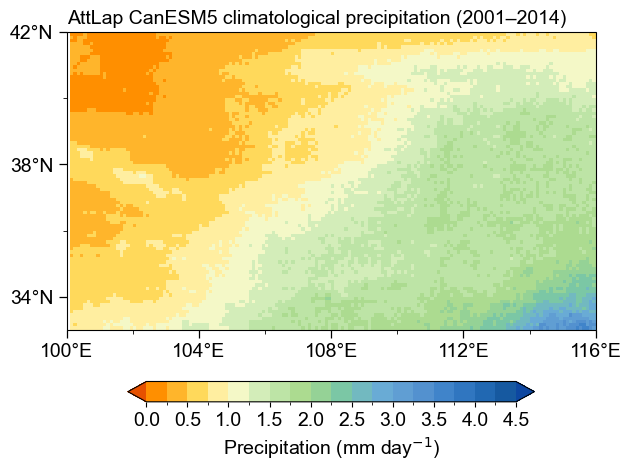

In [9]:
# ------------------------------------------------------------------
# Calculate the 2001–2014 climatological precipitation directly
# from the original daily AttLap NetCDF file.
#
# EXAMPLE_FILE was defined in Section 2:
# CanESM5_historical_AttLap_zlib.nc
#
# The precipitation variable is:
# EXAMPLE_VAR_NAME = "prec"
# ------------------------------------------------------------------

# Reopen the original daily file because it was closed after the
# earlier xarray demonstration.
ds_clim = xr.open_dataset(EXAMPLE_FILE)

if EXAMPLE_VAR_NAME not in ds_clim.data_vars:
    raise KeyError(
        f"Variable '{EXAMPLE_VAR_NAME}' was not found. "
        f"Available variables are: {list(ds_clim.data_vars)}"
    )

pr_daily = ds_clim[EXAMPLE_VAR_NAME]

if TIME_NAME not in pr_daily.dims:
    raise ValueError(
        f"The precipitation variable does not contain the expected "
        f"time dimension '{TIME_NAME}'. Current dimensions: {pr_daily.dims}"
    )


# ----------------------------------------------------------
# Select 2001–2014
# ----------------------------------------------------------

pr_2001_2014 = pr_daily.sel(
    {TIME_NAME: slice("2001-01-01", "2014-12-31")}
)

print("Selected period:")
print(
    pr_2001_2014[TIME_NAME].values[0],
    "to",
    pr_2001_2014[TIME_NAME].values[-1]
)

print("Number of selected time steps:", pr_2001_2014.sizes[TIME_NAME])


# ----------------------------------------------------------
# Calculate the 2001–2014 climatological mean
# ----------------------------------------------------------

pr_clim = pr_2001_2014.mean(
    dim=TIME_NAME,
    skipna=True
)

pr_clim = pr_clim.squeeze(drop=True)

extra_dims = [
    dim for dim in pr_clim.dims
    if dim not in [LAT_NAME, LON_NAME]
]

if extra_dims:
    raise ValueError(
        "The climatological precipitation field contains unexpected "
        f"dimensions: {extra_dims}."
    )

pr_clim = pr_clim.transpose(LAT_NAME, LON_NAME)


# ----------------------------------------------------------
# Select the Loess Plateau domain
# ----------------------------------------------------------

if float(pr_clim[LON_NAME].values[0]) <= float(pr_clim[LON_NAME].values[-1]):
    pr_clim = pr_clim.sel(
        {LON_NAME: slice(lon_min, lon_max)}
    )
else:
    pr_clim = pr_clim.sel(
        {LON_NAME: slice(lon_max, lon_min)}
    )

if float(pr_clim[LAT_NAME].values[0]) <= float(pr_clim[LAT_NAME].values[-1]):
    pr_clim = pr_clim.sel(
        {LAT_NAME: slice(lat_min, lat_max)}
    )
else:
    pr_clim = pr_clim.sel(
        {LAT_NAME: slice(lat_max, lat_min)}
    )

pr_clim = pr_clim.transpose(LAT_NAME, LON_NAME).load()

print("\n2001–2014 climatological precipitation field:")
print(pr_clim)

print(
    "Precipitation range:",
    f"{float(pr_clim.min(skipna=True).item()):.3f} to "
    f"{float(pr_clim.max(skipna=True).item()):.3f} mm day^-1"
)

ds_clim.close()


# ----------------------------------------------------------
# Convert the DataArray to NumPy arrays for plotting
# ----------------------------------------------------------

lon = np.asarray(pr_clim[LON_NAME].values)
lat = np.asarray(pr_clim[LAT_NAME].values)
field = np.asarray(pr_clim.values, dtype=float)

if field.ndim != 2:
    raise ValueError(
        f"Expected a 2-D precipitation field, but got shape {field.shape}."
    )

Lon, Lat = np.meshgrid(lon, lat)


# ----------------------------------------------------------
# Plot the 2001–2014 climatological precipitation field
# Plotting settings are unchanged.
# ----------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7.2, 4.8),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

im = ax.pcolormesh(
    Lon,
    Lat,
    field,
    transform=ccrs.PlateCarree(),
    cmap=cmap_yb,
    norm=norm_yb,
    shading="auto"
)

ax.set_extent(
    [lon_min, lon_max, lat_min, lat_max],
    crs=ccrs.PlateCarree()
)

# Major ticks: 4°
xticks = np.arange(100, 117, 4)
yticks = np.arange(34, 43, 4)

ax.set_xticks(
    xticks,
    crs=ccrs.PlateCarree()
)

ax.set_yticks(
    yticks,
    crs=ccrs.PlateCarree()
)

lon_formatter = LongitudeFormatter(
    number_format=".0f",
    degree_symbol="°",
    dateline_direction_label=False
)

lat_formatter = LatitudeFormatter(
    number_format=".0f",
    degree_symbol="°"
)

ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)

# Minor ticks: 2°
ax.xaxis.set_minor_locator(MultipleLocator(2))
ax.yaxis.set_minor_locator(MultipleLocator(2))

ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    length=6,
    width=0.9,
    labelsize=14
)

ax.tick_params(
    axis="both",
    which="minor",
    direction="out",
    length=3,
    width=0.6,
    labelsize=0
)

ax.set_title(
    "AttLap CanESM5 climatological precipitation (2001–2014)",
    fontsize=14,
    loc="left"
)


# ----------------------------------------------------------
# Horizontal colorbar
# ----------------------------------------------------------

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    boundaries=LEVELS,
    ticks=np.arange(0.0, 4.5 + 0.5, 0.5),
    extend="both",
    pad=0.14,
    fraction=0.055
)

cbar.ax.tick_params(
    labelsize=14
)

cbar.set_label(
    "Precipitation (mm day$^{-1}$)",
    fontsize=14
)

plt.show()


## 10. Save the 2001–2014 climatological precipitation map as an editable PDF

Change the output path below if needed.


In [ ]:
# ------------------------------------------------------------------
# USER INPUT:
# Change the output path below if needed.
# ------------------------------------------------------------------

out_pdf = (
    "/mnt/e/.../"
    "AttLap_CanESM5_2001-2014_climatological_precipitation.pdf"
)

fig.savefig(
    out_pdf,
    format="pdf",
    bbox_inches="tight"
)

print(f"Saved as PDF: {out_pdf}")


Saved as PDF: /mnt/e/4.future precipitation of the Loess Plateau Fanlei/AttLap_CanESM5_2001-2014_climatological_precipitation.pdf
